In [3]:


def load_client_acc(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "list_client_acc.pt"))

def load_client_size(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "list_model_size.pt"))

def load_client_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_client_time.pt"))


def load_acc(exp, cs=False):
    c = load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_acc.pt"))
    if c[0] == 0:
        return c[1:]
    else:
        return c

def load_real_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "time.pt"))

def load_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.time"))

def load_ms(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "model_size.pt"))

def load_fed_avg_acc(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "fed_avg_acc.pt"))

def load_fed_avg_loss(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "fed_avg_loss.pt"))

def load_model_G(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "model_G.pt"))

def load_list_client_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_client_time.pt"))

def load_list_client_density(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_client_density"))
    
def load_train_number(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.train_number"))



            
            

def get_acc_time(acc,time):
    target_acc = [0.83]
    n = 15
    cv_acc = np.convolve(acc, np.ones((n,)) / n, mode='valid')
    cv_time = np.convolve(time, np.ones((n,)) / n, mode='valid')
        # 创建一个字典来存储每个阈值的第一次超过的索引
    exceedances = {threshold: None for threshold in target_acc}
    ac_time = [None]*3
    i = 0
    # 遍历序列，检查每个元素是否超过任何未标记的阈值
    for index, value in enumerate(cv_acc):
        for threshold in target_acc:
            # 如果当前值大于阈值，并且这个阈值还没有找到超过的位置
            if value > threshold and exceedances[threshold] is None:
                exceedances[threshold] = int(cv_time[index])
                ac_time[i] = int(cv_time[index])
                i = i+1
    return ac_time


def find_level(s):
    for level in ['high', 'medium', 'low']:
        if level in s:
            return level
    return None
# 自定义格式化函数，将 x 轴单位改为 10^3
def format_kilo(x, _):
    return f"{int(x / 10000)}"
import re
def plt_photo_acc(exp, exp_legend, fig_name='PR-FL', y_lim=[0.70, 0.90], x_lim=[1, 80000], cov = False):
    import matplotlib.pyplot as plt
    import os
    from os.path import join
    
    # Define the interval for markers
    interval = 20  # You can adjust this value to change the marker density
    # config2 = type("Config", (object,), {"EXP_NAME": "experiment_name"})  # 示例配置
    

    # Create a new figure
    figsize = (7, 5.25)
    plt.figure(figsize=figsize)
    ac_time = {}
    from matplotlib.ticker import FuncFormatter
    # Iterate through all experiments to plot each curve
    for i in range(len(exp)):
        exp_name = exp[i]
        try:
            # Load data
            acc = load_acc(exp_name)
            fed_avg_acc = load_fed_avg_acc(exp_name)
            if  np.mean(acc[-100:-1])>np.mean(fed_avg_acc[-100:-1]):
                fed_avg_acc = acc
            else:
                fed_avg_acc = fed_avg_acc
                
                
            
            if 'fjord' in exp_name or 'heterofl' in exp_name or  'fedrolex' in exp_name:
                level = find_level(exp_name)
                ep2 = 'Time_'+ level
                time = load_time(ep2)
                min_len = min(len(time), len(fed_avg_acc))
                fed_avg_acc = fed_avg_acc[:min_len]
                time = time[:min_len]
            else:
                time = load_time(exp_name)
            cv_acc = np.convolve(fed_avg_acc, np.ones((n,)) / n, mode='valid')
            cv_time = np.convolve(time, np.ones((n,)) / n, mode='valid')
            if not cov: 
                cv_acc = fed_avg_acc
                cv_time = time

            # if 'fed_avg' in exp_name and 'mask_fed_avg' not in exp_name:
            #    interval = int(interval / 2)
            plt.plot(cv_time, cv_acc, linestyle=linestyles[i%len(linestyles)], color=colors[i%len(colors)], linewidth=1, label=exp_legend[i],marker=markers[i%len(markers)],markevery=interval)
        except FileNotFoundError:
            print(f"Skipping {exp_name}. Client selection = {client_sel}.")

    plt.xlabel("Time ($10^4$ s)",fontsize=16)
    plt.ylabel("Test Accuracy",fontsize=16)
    plt.xticks(fontsize=14)  # 增大 x 轴刻度字体
    plt.yticks(fontsize=14)  # 增大 y 轴刻度字体
    plt.xlim(x_lim)
    plt.ylim(y_lim)
    # 使用 FuncFormatter 应用自定义格式
    plt.gca().xaxis.set_major_formatter(FuncFormatter(format_kilo))
    # Add legend
    # Add legend
    plt.legend(
        frameon=False,
        loc="lower right",
        bbox_to_anchor=(1, 0),
        fontsize= 'x-large',
        ncol=2
    )

    # Set grid
    plt.grid(linestyle="--", color='black', lw=0.5, alpha=0.5)

    # Ensure result directories exist and save the figure
    result_path = join("results", config.EXP_NAME)
    fig_path = join(result_path, "figs")

    if not os.path.isdir(fig_path):
        os.makedirs(fig_path)

    plt.savefig(join(fig_path, fig_name + ".png"), dpi=600, bbox_inches='tight')  # Save as PNG format
    plt.show()

def get_time_acc(acc,time,time_line):
    windows = 5
    for index, T in enumerate(time):
        if T>time_line :
            break;
    import numpy as np
    # index = int(10000/25)

    b_mean = np.mean(acc[index-windows:index+windows])*100
    b_std = np.std(acc[index-windows:index+windows])*100

    return [time_line,round(b_mean, 2),f"{b_std:.2g}"]

def plt_time_acc(exp, time_line):
    time_acc = {}
    for i in range(len(exp)):
        exp_name = exp[i]
        try:
            # Load data
            fed_avg_acc = load_fed_avg_acc(exp_name)
            acc = load_acc(exp_name)
            if  np.mean(acc[-50:-1])>np.mean(fed_avg_acc[-50:-1]):
                fed_avg_acc = acc
            else:
                fed_avg_acc = fed_avg_acc
                
            if 'fjord' in exp_name or 'heterofl' in exp_name or  'fedrolex' in exp_name:
                level = find_level(exp_name)
                ep2 = 'Time_'+ level
                time = load_time(ep2)
                min_len = min(len(time), len(fed_avg_acc))
                fed_avg_acc = fed_avg_acc[:min_len]
                time = time[:min_len]
            else:
                time = load_time(exp_name)
            time_acc[exp_name] = get_time_acc(fed_avg_acc,time,time_line)
        except FileNotFoundError:
            print(f"Skipping {exp_name}. Client selection = {client_sel}.")
    import pandas as pd
    import os
    from openpyxl import load_workbook
    for k, v in time_acc.items():
        print(k,v)
    file_path = config.EXP_NAME+'.xlsx'
    sheet_name = 'Sheet1'
    
    # 构造你的数据（你已有的 time_acc）
    df_new = pd.DataFrame([
        {
            'Name': k,
            'Time': v[0],
            'Accuracy': v[1],
            'Std': float(v[2]) if isinstance(v[2], str) else v[2]
        }
        for k, v in time_acc.items()
    ])
    
    # 如果文件存在，读取旧数据；否则创建空DataFrame
    if os.path.exists(file_path):
        df_old = pd.read_excel(file_path, sheet_name=sheet_name)
        df_combined = pd.concat([df_old, df_new], ignore_index=True)
    
        # 以追加模式打开并替换已有 sheet
        with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
            df_combined.to_excel(writer, sheet_name=sheet_name, index=False)
    else:
        # 如果文件不存在，直接写入新数据
        df_new.to_excel(file_path, index=False)

%matplotlib inline
import matplotlib.pyplot as plt
# Create data
import numpy as np
import os
from os.path import join
import matplotlib.pyplot as plt
from itertools import product
from utils.save_load import load
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

dataset_name = "FEMNIST"
import configs.femnist as config
client_sel = False
time_lim = (-1000, 60000)
acc_lim = (0.0, 0.9)
lottery_ticket_acc_lim = (0.7, 0.9)
n = 10

result_path = join("results", config.EXP_NAME)
if not os.path.isdir(f"results/{config.EXP_NAME}/figs"):
    os.makedirs(f"results/{config.EXP_NAME}/figs")
fig_path = join(result_path, "figs")
linestyles = [
    (0, (2, 2)), '-', '--', '-.', ':',
    (0, (5, 1)), (0, (3, 5, 1, 5)),  # 原有7种
    (0, (1, 10)), (0, (3, 1, 1, 1)), (0, (5, 10)), 
    (0, (3, 1, 3, 1, 1, 1)), (0, (7, 3)), (0, (5, 2, 1, 2))
]

colors = [
    'red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink',  # 原有7种
    'cyan', 'magenta', 'olive', 'teal', 'navy', 'gray'
]

markers = [
    '^', 'o', '*', 'D', 's', 'p', 'v',  # 原有7种
    '<', '>', 'h', 'H', 'X', '+'
]


In [5]:
import os
list = os.listdir(result_path)
list = sorted(list)
list

['.ipynb_checkpoints',
 '1',
 'Ablation_iid_high__gmr_FEMNIST_10_25_bp',
 'Ablation_iid_low__gmr_FEMNIST_10_25_bp',
 'Ablation_iid_medium__gmr_FEMNIST_10_25_bp',
 'Ablation_niid_high__gmr_FEMNIST_10_25_bp',
 'Ablation_niid_low__gmr_FEMNIST_10_25_bp',
 'Ablation_niid_medium__gmr_FEMNIST_10_25_bp',
 'FEMNIST',
 'Time_high',
 'Time_low',
 'Time_medium',
 'figs',
 'iid_1.0_high_gradient_avg_FEMNIST',
 'iid_1.0_high_mask_fed_avg_FEMNIST',
 'iid_1.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]',
 'iid_1.0_low_gradient_avg_FEMNIST',
 'iid_1.0_low_mask_fed_avg_FEMNIST',
 'iid_1.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]',
 'iid_1.0_medium_gradient_avg_FEMNIST',
 'iid_1.0_medium_mask_fed_avg_FEMNIST',
 'iid_1.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]',
 'iid_2.0_high_asyn_FEMNIST',
 'iid_2.0_high_gradient_avg_FEMNIST',
 'iid_2.0_high_gradient_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]',
 'iid_2.0_high_mask_fed_avg_FEMNIST',
 'iid_2.0_high_mask_fed_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]',
 

iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_10 [80000, 82.77, '0.21']
iid_high__fed_avg_FEMNIST_0.5_10_5_bp [80000, 76.81, '0.4']
iid_high_fed_asyn_FEMNIST_0.5 [80000, 82.04, '0.17']
iid_high_heterofl_FEMNIST [80000, 82.44, '0.12']
iid_high_fedrolex_FEMNIST [80000, 80.26, '0.23']
iid_high_fjord_FEMNIST [80000, 82.95, '0.13']
iid_high_fiarse_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_w_10 [80000, 81.64, '0.21']
iid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_1 [80000, 83.18, '0.31']
iid_medium__fed_avg_FEMNIST_0.5_10_5_bp [80000, 77.11, '0.27']
iid_medium_fed_asyn_FEMNIST_0.5 [80000, 82.74, '0.22']
iid_medium_heterofl_FEMNIST [80000, 76.78, '0.99']
iid_medium_fedrolex_FEMNIST [80000, 82.36, '0.15']
iid_medium_fjord_FEMNIST [80000, 82.96, '0.18']
iid_medium__fiarse_FEMNIST_0.5_10_w_25_bp [80000, 81.87, '0.16']
iid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_1 [80000, 84.13, '0.24']
iid_low__fed_avg_FEMNIST_0.5_10_5_bp [80000, 77.26, '0.23']
iid_low_fed_asyn_FEMNIST_0.5 [80

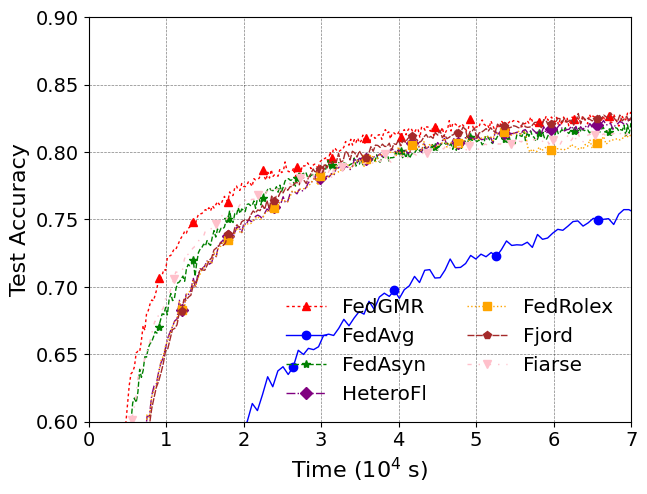

medium_iid


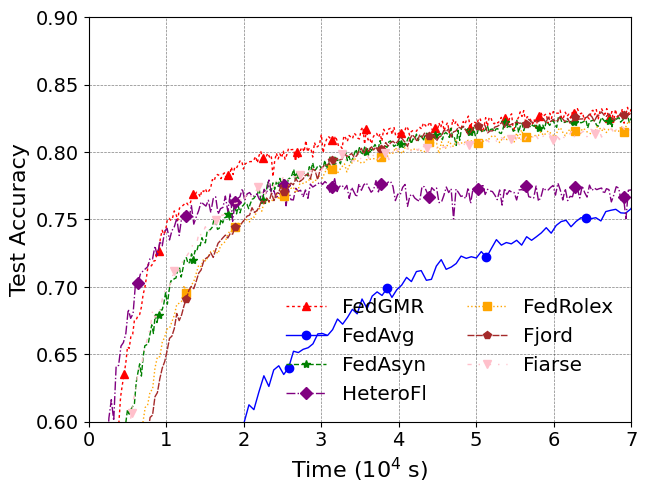

low_iid


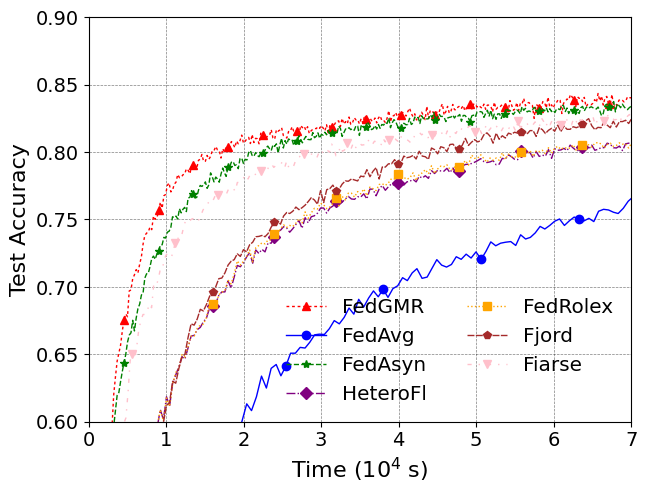

high_niid


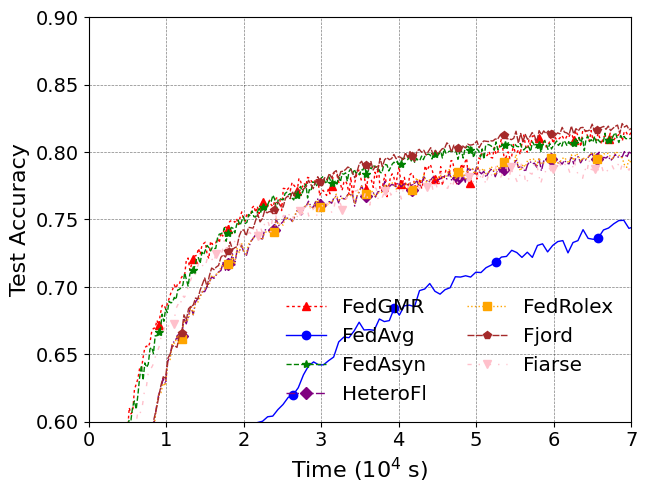

medium_niid


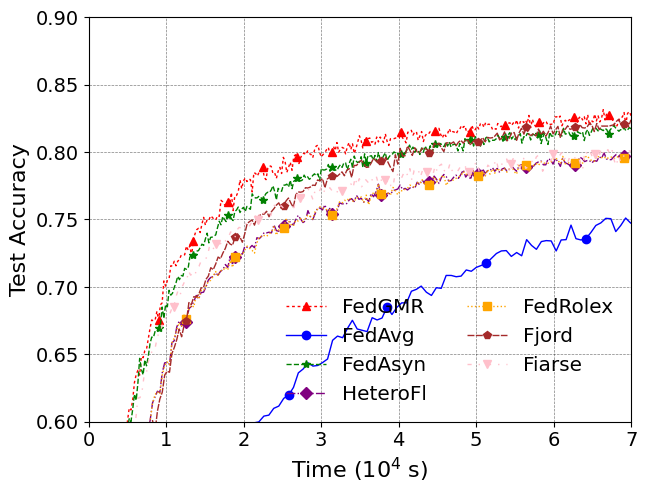

low_niid


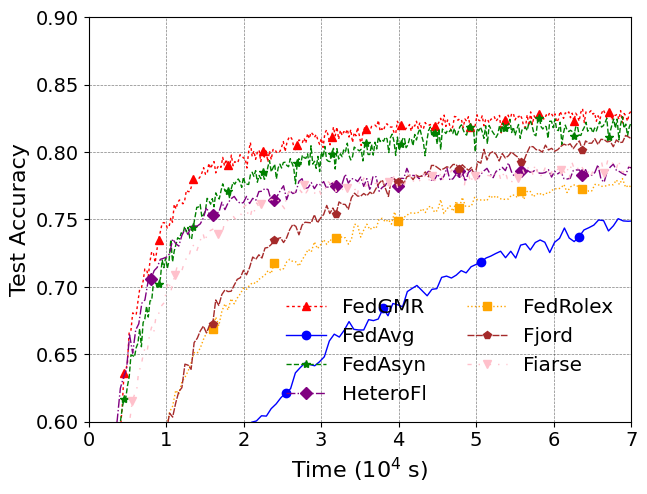

In [10]:
exp_list =[

'iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_10',
'iid_high__fed_avg_FEMNIST_0.5_10_5_bp',
'iid_high_fed_asyn_FEMNIST_0.5',
'iid_high_heterofl_FEMNIST',
'iid_high_fedrolex_FEMNIST',
'iid_high_fjord_FEMNIST',
'iid_high_fiarse_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_w_10',


'iid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_1',
'iid_medium__fed_avg_FEMNIST_0.5_10_5_bp',
'iid_medium_fed_asyn_FEMNIST_0.5',
'iid_medium_heterofl_FEMNIST',
'iid_medium_fedrolex_FEMNIST',
'iid_medium_fjord_FEMNIST',
'iid_medium__fiarse_FEMNIST_0.5_10_w_25_bp',


'iid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_1',
'iid_low__fed_avg_FEMNIST_0.5_10_5_bp',
'iid_low_fed_asyn_FEMNIST_0.5',
'iid_low_heterofl_FEMNIST',
'iid_low_fedrolex_FEMNIST',
'iid_low_fjord_FEMNIST',
'iid_low__fiarse_FEMNIST_0.5_10_w_25_bp',

'niid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_15',
'niid_high__fed_avg_FEMNIST_0.5_10_5_bp',    
'niid_high_fed_asyn_FEMNIST_0.5',
'niid_high_heterofl_FEMNIST',
'niid_high_fedrolex_FEMNIST',
'niid_high_fjord_FEMNIST',
'niid_high__fiarse_FEMNIST_0.5_10_w_25_bp',


'niid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]',
'niid_medium__fed_avg_FEMNIST_0.5_10_5_bp',
'niid_medium_fed_asyn_FEMNIST_0.5',
'niid_medium_heterofl_FEMNIST',
'niid_medium_fedrolex_FEMNIST',
'niid_medium_fjord_FEMNIST',
'niid_medium__fiarse_FEMNIST_0.5_10_w_25_bp',


'niid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_2',
'niid_low__fed_avg_FEMNIST_0.5_10_5_bp',    
'niid_low_fed_asyn_FEMNIST_0.5', 
'niid_low_heterofl_FEMNIST',
'niid_low_fedrolex_FEMNIST',
'niid_low_fjord_FEMNIST',
'niid_low__fiarse_FEMNIST_0.5_10_w_25_bp',


]

fig_name_list = ['high_iid','medium_iid','low_iid','high_niid','medium_niid','low_niid',]
exp_legend = [
 'FedGMR',
     'FedAvg',
    'FedAsyn',
'HeteroFl',
'FedRolex',
'Fjord',
 'Fiarse',
]


# plt_time_acc(exp_list, 20000)
# plt_time_acc(exp_list, 50000)
plt_time_acc(exp_list, 80000)
i = 0 
while i < len(exp_list):
    exp = exp_list[i:i+len(exp_legend)]
    fn = fig_name_list[int(i/len(exp_legend))]
    print(fn)
    fn = fn+'baseline'
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.60,0.90],x_lim= [0,70000])
    i= i+len(exp_legend)
    



iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05] [7000, 66.9, '1.3']
iid_2.0_high_asyn_FEMNIST [7000, 72.49, '0.82']
iid_high_gmr_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_10 [7000, 66.84, '1.3']
iid_2.0_high_gradient_avg_FEMNIST [7000, 54.25, '2']
iid_2.0_high_mask_fed_avg_FEMNIST [7000, 53.94, '1.7']
iid_2.0_high_gradient_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05] [7000, 54.4, '1.6']
iid_2.0_high_mask_fed_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05] [7000, 27.87, '3.1']
iid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05] [7000, 67.21, '1.5']
iid_2.0_medium_asyn_FEMNIST [7000, 72.76, '0.65']
Ablation_iid_medium__gmr_FEMNIST_10_25_bp [7000, 67.66, '1.4']
iid_2.0_medium_gradient_avg_FEMNIST [7000, 57.46, '2']
iid_2.0_medium_mask_fed_avg_FEMNIST [7000, 54.03, '1.8']
iid_2.0_medium_gradient_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05] [7000, 56.86, '1.7']
iid_2.0_medium_mask_fed_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05] [7000, 22.58, '2.1']
iid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05] [7000, 69.66, '1.3']
i

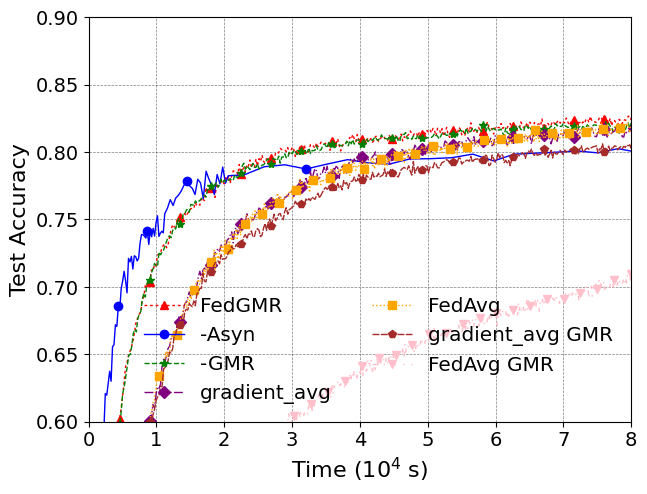

medium_iidagg


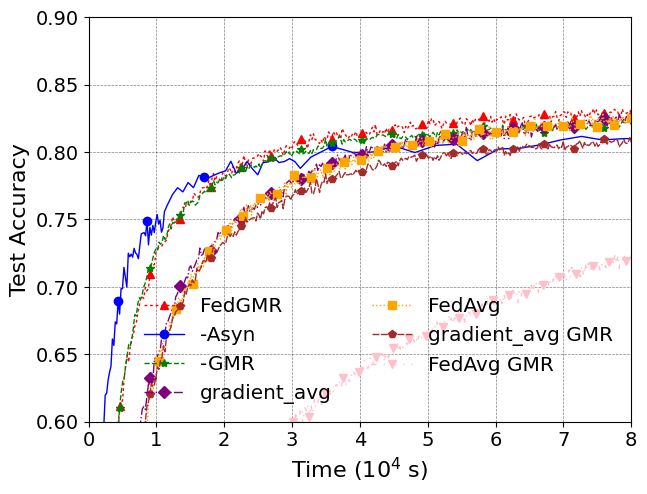

low_iidagg


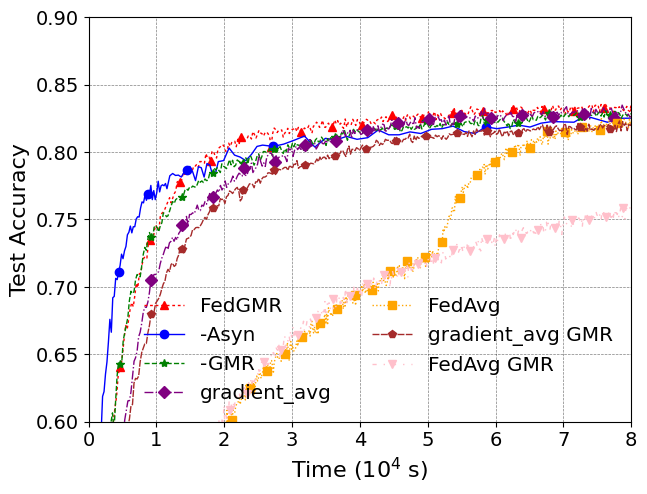

high_niidagg


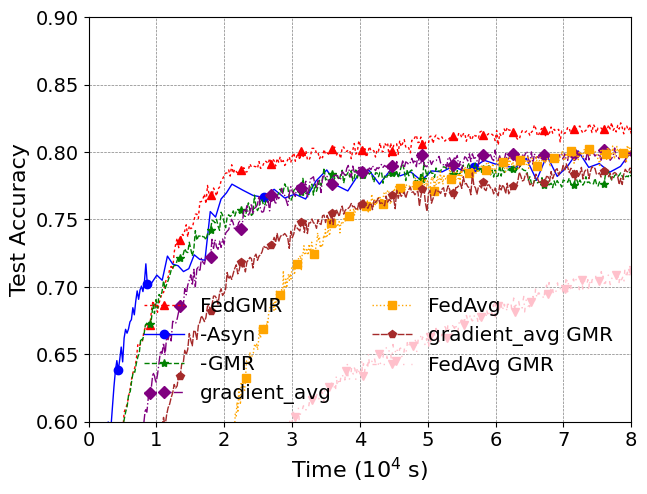

medium_niidagg


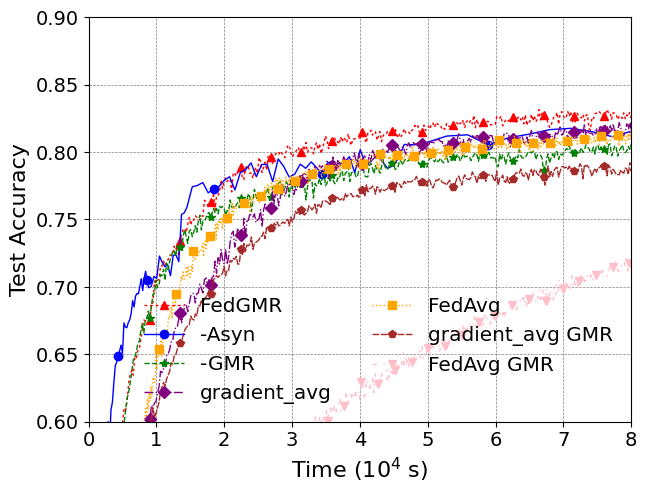

low_niidagg


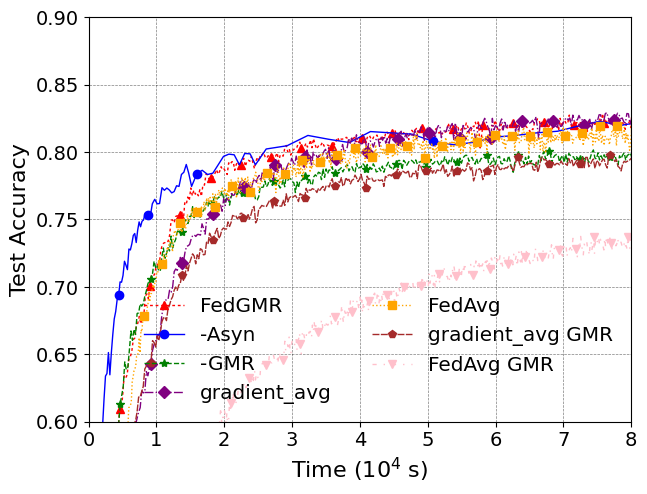

In [9]:
exp_list =[

'iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]',
'iid_2.0_high_asyn_FEMNIST',
'iid_high_gmr_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]_10',
'iid_2.0_high_gradient_avg_FEMNIST',
'iid_2.0_high_mask_fed_avg_FEMNIST',
'iid_2.0_high_gradient_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]',
 'iid_2.0_high_mask_fed_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]',

 'iid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]',
 'iid_2.0_medium_asyn_FEMNIST',
 'Ablation_iid_medium__gmr_FEMNIST_10_25_bp',
 'iid_2.0_medium_gradient_avg_FEMNIST',
 'iid_2.0_medium_mask_fed_avg_FEMNIST',
'iid_2.0_medium_gradient_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]',
 'iid_2.0_medium_mask_fed_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]',  

'iid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]',
'iid_2.0_low_asyn_FEMNIST',
 'Ablation_iid_low__gmr_FEMNIST_10_25_bp',
'iid_2.0_low_gradient_avg_FEMNIST',
'iid_2.0_low_mask_fed_avg_FEMNIST',
'iid_2.0_low_gradient_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]',
 'iid_2.0_low_mask_fed_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]',

 'niid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]',
 'niid_2.0_high_asyn_FEMNIST',
 'Ablation_niid_high__gmr_FEMNIST_10_25_bp',
'niid_2.0_high_gradient_avg_FEMNIST',
'niid_2.0_high_mask_fed_avg_FEMNIST', 
 'niid_2.0_high_gradient_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]',
 'niid_2.0_high_mask_fed_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]',

 'niid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]',
 'niid_2.0_medium_asyn_FEMNIST',
 'Ablation_niid_medium__gmr_FEMNIST_10_25_bp',
'niid_2.0_medium_gradient_avg_FEMNIST',
'niid_2.0_medium_mask_fed_avg_FEMNIST',
 'niid_2.0_medium_gradient_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]',
 'niid_2.0_medium_mask_fed_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]',

 'niid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]',
 'niid_2.0_low_asyn_FEMNIST',
 'Ablation_niid_low__gmr_FEMNIST_10_25_bp',
'niid_2.0_low_gradient_avg_FEMNIST',
'niid_2.0_low_mask_fed_avg_FEMNIST',
 'niid_2.0_low_gradient_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]',
 'niid_2.0_low_mask_fed_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]',

]
fig_name_list = ['high_iidagg','medium_iidagg','low_iidagg','high_niidagg','medium_niidagg','low_niidagg',]
exp_legend = ['FedGMR','-Asyn','-GMR','gradient_avg','FedAvg','gradient_avg GMR','FedAvg GMR']


plt_time_acc(exp_list, 7000)
plt_time_acc(exp_list, 70000)
i = 0 
while i < len(exp_list):
    exp = exp_list[i:i+len(exp_legend)]
    fn = fig_name_list[int(i/len(exp_legend))]
    print(fn)
    fn = fn+'patience'
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.60,0.90],x_lim= [0,80000])
    i= i+len(exp_legend)


 'niid_medium_ims_FEMNIST',
 'niid_medium_pure_FEMNIST'



In [19]:
exp_list =[



 '2niid_2.0_low_pr_fl_FEMNIST',

]
fig_name_list = ['high_iidagg','medium_iidagg','low_iidagg','high_niidagg','medium_niidagg','low_niidagg',]
exp_legend = ['FedGMR','-Asyn','-GMR','gradient_avg','FedAvg','gradient_avg GMR','FedAvg GMR']


plt_time_acc(exp_list, 7000)
plt_time_acc(exp_list, 70000)
# i = 0 
# while i < len(exp_list):
#     exp = exp_list[i:i+len(exp_legend)]
#     fn = fig_name_list[int(i/len(exp_legend))]
#     print(fn)
#     fn = fn+'patience'
#     plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.60,0.90],x_lim= [0,80000])
#     i= i+len(exp_legend)


#  'niid_medium_ims_FEMNIST',
#  'niid_medium_pure_FEMNIST'



2niid_2.0_low_pr_fl_FEMNIST [7000, 60.23, '1.8']
2niid_2.0_low_pr_fl_FEMNIST [70000, 82.19, '0.51']


niid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05] [70000, 82.73, '0.29']
niid_2.0_medium_asyn_FEMNIST [70000, 81.31, '0.34']
Ablation_niid_medium__gmr_FEMNIST_10_25_bp [70000, 79.99, '0.26']
niid_medium_buff_FEMNIST [70000, 81.87, '0.18']
niid_medium_ims_FEMNIST [70000, 82.03, '0.19']
niid_medium_pure_FEMNIST [70000, 82.01, '0.18']
niid_2.0_medium_gradient_avg_FEMNIST [70000, 81.45, '0.25']
niid_2.0_medium_mask_fed_avg_FEMNIST [70000, 80.81, '0.21']
niid_2.0_medium_gradient_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05] [70000, 78.75, '0.23']
niid_2.0_medium_mask_fed_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05] [70000, 70.09, '0.22']
high_iidagg


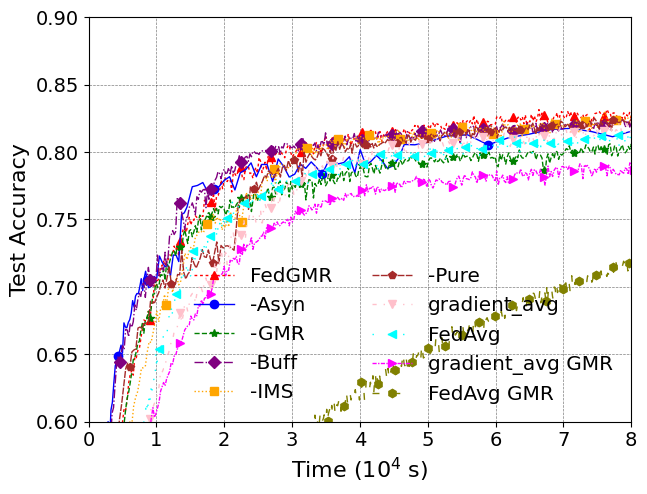

In [8]:
exp_list =[


 'niid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]',
 'niid_2.0_medium_asyn_FEMNIST',
 'Ablation_niid_medium__gmr_FEMNIST_10_25_bp',
 'niid_medium_buff_FEMNIST',
 'niid_medium_ims_FEMNIST',
 'niid_medium_pure_FEMNIST',
'niid_2.0_medium_gradient_avg_FEMNIST',
'niid_2.0_medium_mask_fed_avg_FEMNIST',
 'niid_2.0_medium_gradient_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]',
 'niid_2.0_medium_mask_fed_avg_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]',



]
fig_name_list = ['high_iidagg','medium_iidagg','low_iidagg','high_niidagg','medium_niidagg','low_niidagg',]
exp_legend = ['FedGMR','-Asyn','-GMR','-Buff','-IMS','-Pure','gradient_avg','FedAvg','gradient_avg GMR','FedAvg GMR']


# plt_time_acc(exp_list, 7000)
plt_time_acc(exp_list, 70000)
i = 0 
while i < len(exp_list):
    exp = exp_list[i:i+len(exp_legend)]
    fn = fig_name_list[int(i/len(exp_legend))]
    print(fn)
    fn = fn+'patience'
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.60,0.90],x_lim= [0,80000])
    i= i+len(exp_legend)






In [13]:
import os
list = os.listdir(result_path)
list = sorted(list)
list
filtered = [x for x in list if any(key in x.lower() for key in ["ims", "pure", "buff"])]
filtered

['iid_high_buff_FEMNIST',
 'iid_high_ims_FEMNIST',
 'iid_high_pure_FEMNIST',
 'iid_low_buff_FEMNIST',
 'iid_low_ims_FEMNIST',
 'iid_low_pure_FEMNIST',
 'iid_medium_buff_FEMNIST',
 'iid_medium_ims_FEMNIST',
 'iid_medium_pure_FEMNIST',
 'niid_high_buff_FEMNIST',
 'niid_high_ims_FEMNIST',
 'niid_high_pure_FEMNIST',
 'niid_low_buff_FEMNIST',
 'niid_low_buff_FEMNIST_[1, 0.5, 0.2, 0.1, 0.05]',
 'niid_low_ims_FEMNIST',
 'niid_low_pure_FEMNIST',
 'niid_medium_buff_FEMNIST',
 'niid_medium_ims_FEMNIST',
 'niid_medium_pure_FEMNIST']

iid_high_buff_FEMNIST [70000, 82.07, '0.2']
iid_high_ims_FEMNIST [70000, 82.29, '0.19']
iid_high_pure_FEMNIST [70000, 81.3, '0.27']
iid_medium_buff_FEMNIST [70000, 82.79, '0.15']
iid_medium_ims_FEMNIST [70000, 82.59, '0.27']
iid_medium_pure_FEMNIST [70000, 82.17, '0.16']
iid_low_buff_FEMNIST [70000, 83.36, '0.17']
iid_low_ims_FEMNIST [70000, 83.21, '0.18']
iid_low_pure_FEMNIST [70000, 83.02, '0.16']
niid_high_buff_FEMNIST [70000, 81.37, '0.33']
niid_high_ims_FEMNIST [70000, 81.6, '0.26']
niid_high_pure_FEMNIST [70000, 81.35, '0.26']
niid_medium_buff_FEMNIST [70000, 81.87, '0.18']
niid_medium_ims_FEMNIST [70000, 82.03, '0.19']
niid_medium_pure_FEMNIST [70000, 82.01, '0.18']
niid_low_buff_FEMNIST [70000, 82.78, '0.36']
niid_low_ims_FEMNIST [70000, 82.86, '0.22']
niid_low_pure_FEMNIST [70000, 82.45, '0.34']
high_iidagg


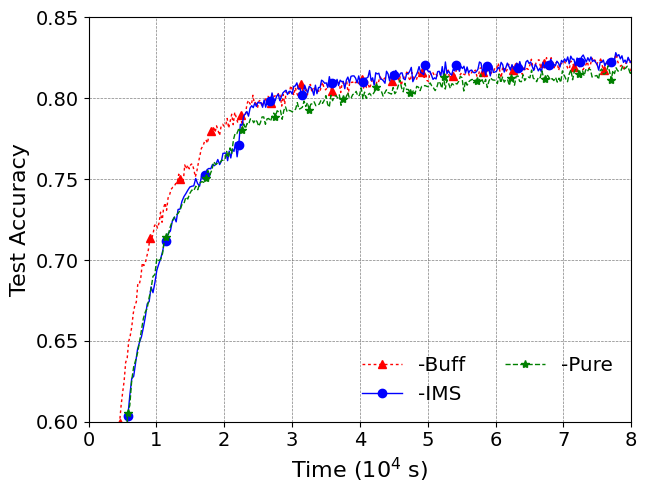

medium_iidagg


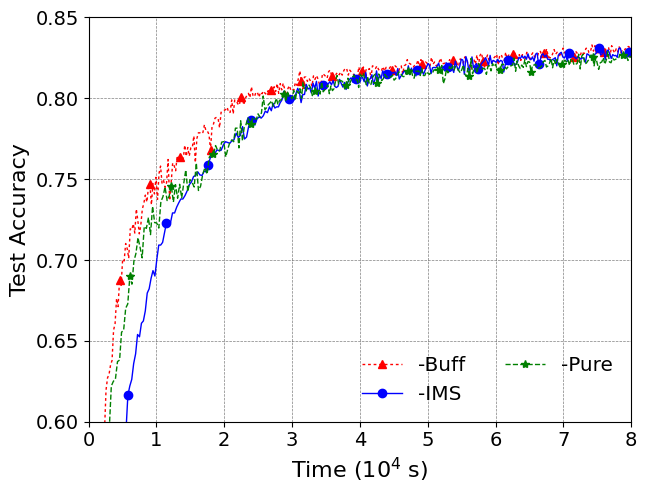

low_iidagg


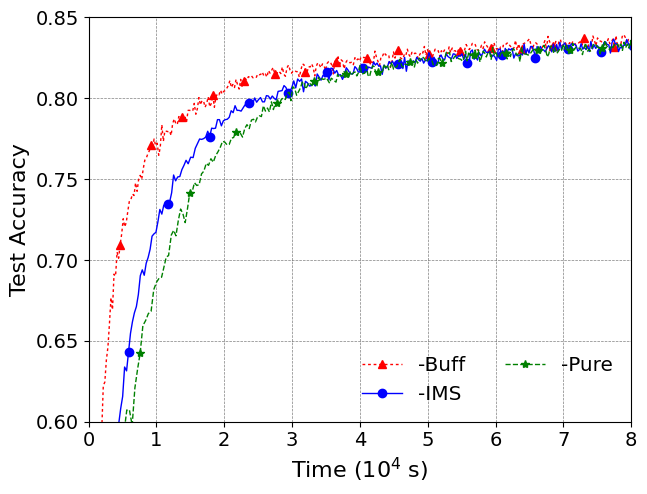

high_niidagg


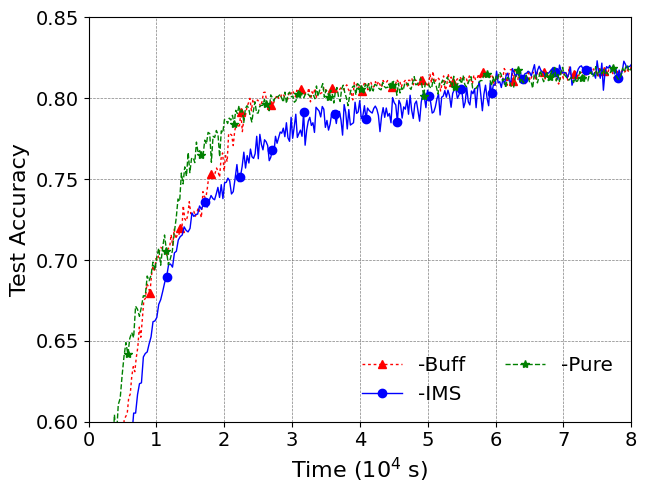

medium_niidagg


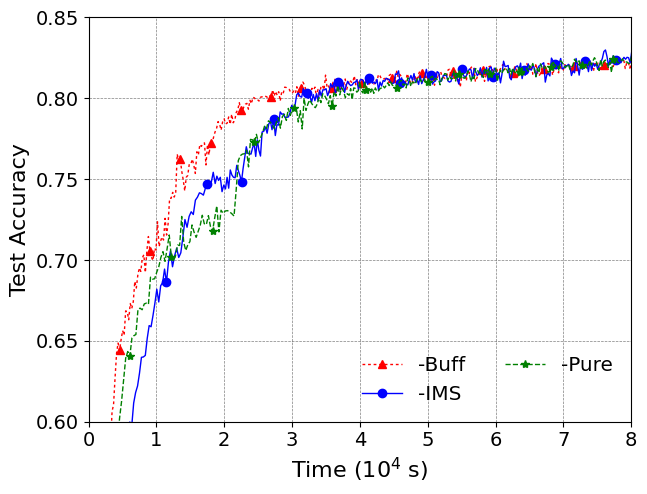

low_niidagg


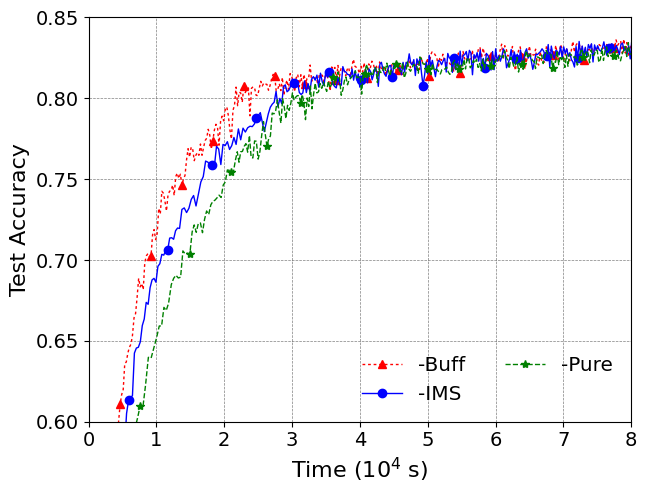

In [17]:
exp_list =[


'iid_high_buff_FEMNIST',
 'iid_high_ims_FEMNIST',
 'iid_high_pure_FEMNIST',

 'iid_medium_buff_FEMNIST',
 'iid_medium_ims_FEMNIST',
 'iid_medium_pure_FEMNIST',

'iid_low_buff_FEMNIST',
 'iid_low_ims_FEMNIST',
 'iid_low_pure_FEMNIST',

'niid_high_buff_FEMNIST',
 'niid_high_ims_FEMNIST',
 'niid_high_pure_FEMNIST',
    
 'niid_medium_buff_FEMNIST',
 'niid_medium_ims_FEMNIST',
 'niid_medium_pure_FEMNIST',
    
 'niid_low_buff_FEMNIST',
 'niid_low_ims_FEMNIST',
 'niid_low_pure_FEMNIST',




]
fig_name_list = ['high_iidagg','medium_iidagg','low_iidagg','high_niidagg','medium_niidagg','low_niidagg',]
exp_legend = ['-Buff','-IMS','-Pure']


# plt_time_acc(exp_list, 7000)
plt_time_acc(exp_list, 70000)
i = 0 
while i < len(exp_list):
    exp = exp_list[i:i+len(exp_legend)]
    fn = fig_name_list[int(i/len(exp_legend))]
    print(fn)
    fn = fn+'patience'
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.60,0.85],x_lim= [0,80000])
    i= i+len(exp_legend)






iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_1 [70000, 82.13, '0.34']
iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_2 [70000, 81.47, '0.25']
iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_3 [70000, 81.15, '0.17']
iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_4 [70000, 81.9, '0.26']
iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05] [70000, 82.24, '0.14']
iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_6 [70000, 82.23, '0.15']
iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_7 [70000, 82.53, '0.26']
iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_8 [70000, 82.72, '0.14']
iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_9 [70000, 82.25, '0.18']
iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_10 [70000, 82.61, '0.29']
iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_11 [70000, 81.9, '0.15']
iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_12 [70000, 81.81, '0.089']
iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05

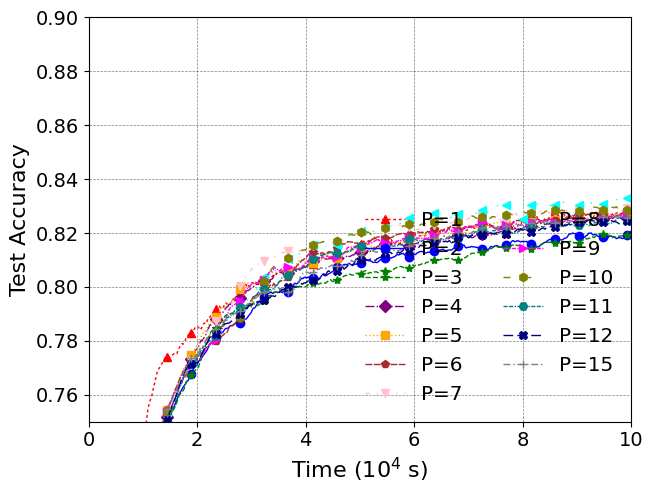

medium_iid


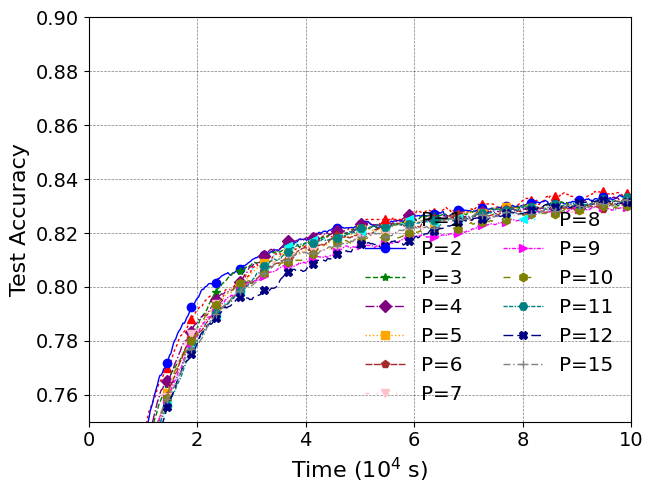

low_iid


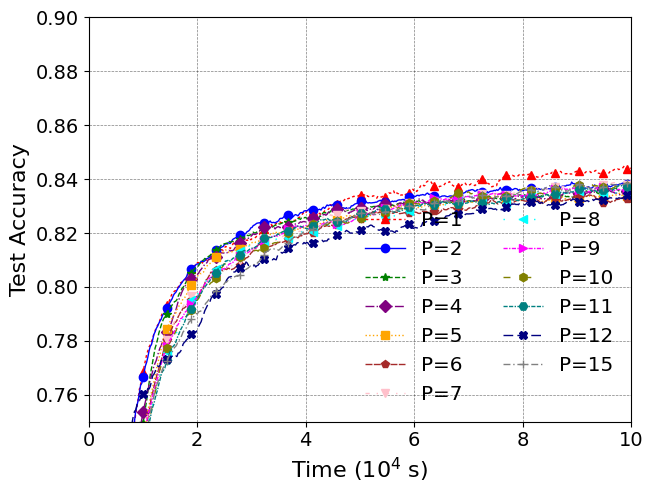

high_niid


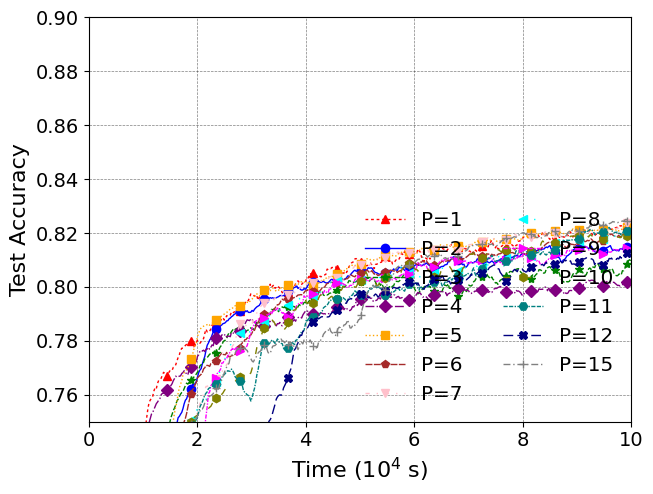

medium_niid


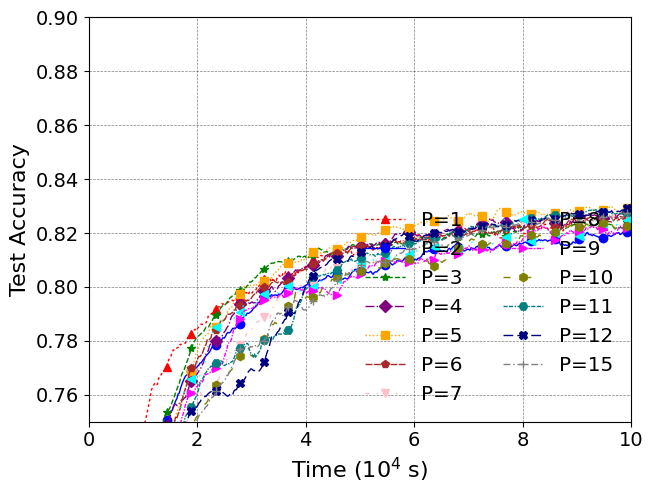

low_niid


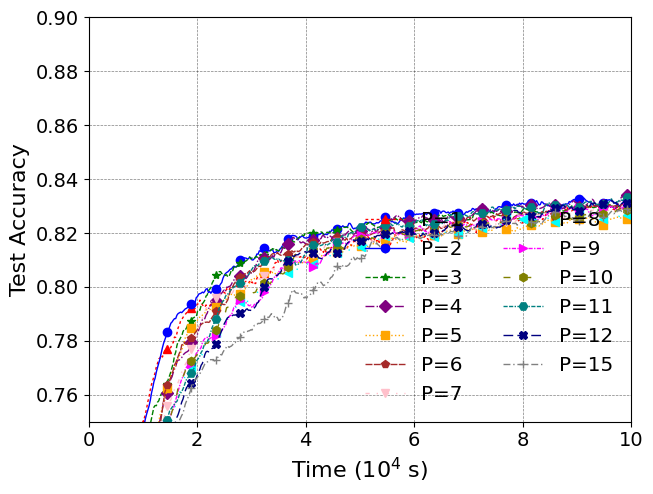

In [7]:

exp_list =[
 'iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_1',
 'iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_2',
'iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_3',
'iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_4',
 'iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]',
'iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_6',
 'iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_7',
'iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_8',
'iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_9',
 'iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_10',
'iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_11',
'iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_12',
 'iid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_15',

    
    'iid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_1',
    'iid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_2',
    'iid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_3',
    'iid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_4',
    'iid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]',   # 省略即 _5
    'iid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_6',
    'iid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_7',
    'iid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_8',
    'iid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_9',
    'iid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_10',
    'iid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_11',
    'iid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_12',
    'iid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_15',


    'iid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_1',
    'iid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_2',
    'iid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_3',
    'iid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_4',
    'iid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]',   # 省略即 _5
    'iid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_6',
    'iid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_7',
    'iid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_8',
    'iid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_9',
    'iid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_10',
    'iid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_11',
    'iid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_12',
    'iid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_15',




    'niid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_1',
    'niid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_2',
    'niid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_3',
    'niid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_4',
    'niid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]',   # 省略即 _5
    'niid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_6',
    'niid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_7',
    'niid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_8',
    'niid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_9',
    'niid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_10',
    'niid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_11',
    'niid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_12',
    'niid_2.0_high_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_15',



    'niid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_1',
    'niid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_2',
    'niid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_3',
    'niid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_4',
    'niid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]',   # 省略即 _5
    'niid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_6',
    'niid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_7',
    'niid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_8',
    'niid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_9',
    'niid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_10',
    'niid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_11',
    'niid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_12',
    'niid_2.0_medium_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_15',


    'niid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_1',
    'niid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_2',
    'niid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_3',
    'niid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_4',
    'niid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]',   # 省略即 _5
    'niid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_6',
    'niid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_7',
    'niid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_8',
    'niid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_9',
    'niid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_10',
    'niid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_11',
    'niid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_12',
    'niid_2.0_low_pr_fl_FEMNIST_[1.0, 0.5, 0.2, 0.1, 0.05]_15',


]

fig_name_list = ['high_iid','medium_iid','low_iid','high_niid','medium_niid','low_niid',]
exp_legend = ['P=1','P=2','P=3','P=4','P=5','P=6','P=7','P=8','P=9','P=10','P=11','P=12','P=15']

   
plt_time_acc(exp_list, 70000)
i = 0 
while i < len(exp_list):
    exp = exp_list[i:i+len(exp_legend)]
    fn = fig_name_list[int(i/len(exp_legend))]
    print(fn)
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.75,0.90],x_lim= [0,100000],cov = True)
    i= i+len(exp_legend)
    

